<a href="https://colab.research.google.com/github/zeets13/Flaggr_Project/blob/main/Notebook/4_Binary_Distilbert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Distilbert for binary classification**

In [ ]:
!pip install -q transformers datasets accelerate

In [ ]:
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

Loading the splitted dataset

In [ ]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/hate_speech_data/binary_label_train_15000.csv"
)
valid_df = pd.read_csv(
    "/content/drive/MyDrive/hate_speech_data/binary_label_validation_15000.csv"
)
test_df = pd.read_csv(
    "/content/drive/MyDrive/hate_speech_data/binary_label_test_15000.csv"
)

In [ ]:
print(train_df.head())
print(train_df.columns)

   comment_id                                               text  \
0       35106  Ida Odinga: Joyce had been a leader since her ...   
1       39405  Woman I AM not a racist and you will not label...   
2       24088  The Portuguese left enclaves of Catholicism in...   
3       29604           Bitch On My Dick... She Know What It Is!   
4       39088  You could never fuck me like this, because you...   

        hatespeech  hate_speech_label  binary_label  
0       [0.0, 0.0]                0.0             0  
1            [0.0]                0.0             0  
2       [0.0, 0.0]                0.0             0  
3  [0.0, 2.0, 0.0]                0.0             0  
4  [0.0, 0.0, 0.0]                0.0             0  
Index(['comment_id', 'text', 'hatespeech', 'hate_speech_label',
       'binary_label'],
      dtype='object')


Renaming columns

In [ ]:
train_df = train_df.rename(
    columns={"binary_label": "labels"}
)

valid_df = valid_df.rename(
    columns={"binary_label": "labels"}
)

test_df = test_df.rename(
    columns={"binary_label": "labels"}
)

In [ ]:
print(train_df.columns)

Index(['comment_id', 'text', 'hatespeech', 'hate_speech_label', 'labels'], dtype='object')


Preparing dataset

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "labels"]],
    preserve_index=False
)

valid_dataset = Dataset.from_pandas(
    valid_df[["text", "labels"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "labels"]],
    preserve_index=False
)

In [ ]:
print(train_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 12000
})


Loading tokenizer for Distilbert

In [ ]:

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=192
    )

In [ ]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

valid_dataset = valid_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Loading Distilbert model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Calculating weights for each class to handle imbalance

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["labels"].values
)

print("Class weights:", class_weights)

Class weights: [0.66822586 1.98609732]


In [ ]:
from transformers import Trainer
import torch
import torch.nn as nn


class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        weights = torch.tensor(
            class_weights,
            dtype=torch.float,
            device=logits.device
        )

        loss_fn = nn.CrossEntropyLoss(
            weight=weights
        )

        loss = loss_fn(
            logits,
            labels
        )

        if return_outputs:
            return loss, outputs

        return loss

Defining evaluation metrices

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=-1
    ).numpy()

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="binary",
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    roc_auc = roc_auc_score(
        labels,
        probabilities[:, 1]
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

Preparing training arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_binary_results",

    num_train_epochs=5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,

    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    report_to="none"
)

Creating the trainer

In [ ]:
from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

Model training

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.425857,0.417814,0.864000,0.733871,0.722222,0.728000,0.910633
2,0.316432,0.426847,0.856000,0.688372,0.783069,0.732673,0.911654
3,0.227441,0.596152,0.861333,0.721354,0.732804,0.727034,0.906028
4,0.152945,0.849868,0.857333,0.719251,0.711640,0.715426,0.899023


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.28066863759358723, metrics={'train_runtime': 939.9012, 'train_samples_per_second': 63.836, 'train_steps_per_second': 3.99, 'total_flos': 2384413175808000.0, 'train_loss': 0.28066863759358723, 'epoch': 4.0})

Evaluating performance on test set

In [ ]:
test_results = trainer.evaluate(
    eval_dataset=test_dataset
)


for key, value in test_results.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.152945,0.435702,4,0.850000,0.680095,0.761273,0.718398,0.909441


===== TEST RESULTS =====
eval_loss: 0.4357019364833832
eval_accuracy: 0.85
eval_precision: 0.6800947867298578
eval_recall: 0.7612732095490716
eval_f1: 0.718397997496871
eval_roc_auc: 0.9094411284665223


Evaluation on test set

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(test_dataset)

logits = predictions.predictions
labels = predictions.label_ids

test_predictions = np.argmax(logits, axis=-1)

print("===== DISTILBERT TEST CLASSIFICATION REPORT =====")

print(
    classification_report(
        labels,
        test_predictions,
        target_names=["Non-Hate", "Hate"],
        digits=4
    )
)

===== DISTILBERT TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Non-Hate     0.9165    0.8798    0.8978      1123
        Hate     0.6801    0.7613    0.7184       377

    accuracy                         0.8500      1500
   macro avg     0.7983    0.8205    0.8081      1500
weighted avg     0.8571    0.8500    0.8527      1500



Confusion matrix

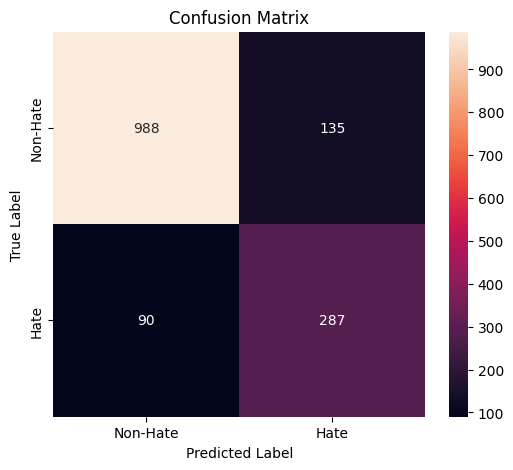

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(labels, test_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Hate", "Hate"],
    yticklabels=["Non-Hate", "Hate"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Normalized confusion matrix

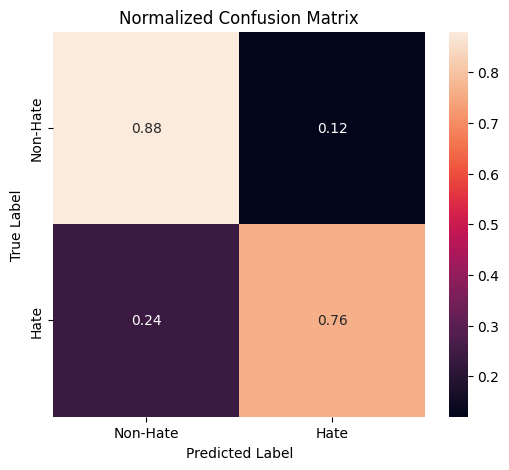

In [ ]:
cm_normalized = confusion_matrix(
    labels,
    test_predictions,
    normalize="true"
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=["Non-Hate", "Hate"],
    yticklabels=["Non-Hate", "Hate"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()

Saving the best model

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/hate_speech_data/model_binary_distilbert"

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/hate_speech_data/model_binary_distilbert
